# 02 – Thử nghiệm Decision Tree & XGBoost + Hyperparameter Tuning
Notebook bổ sung cho `01_HR_Analytics.ipynb` (phần việc: *thử thêm thuật toán ML và tối ưu tham số*).

Điểm khác so với notebook 01:
- Decision Tree được đưa vào **so sánh bằng Stratified CV** và **tinh chỉnh bằng GridSearchCV** (ở notebook 01 chỉ huấn luyện 1 lần để xem importance).
- XGBoost được tìm tham số **rộng hơn** (`n_iter=40`, thêm `gamma`, `reg_alpha`) rồi tinh lại bằng GridSearch quanh vùng tốt nhất.
- Mọi so sánh dùng cùng split, cùng `cv`, cùng metric (ROC-AUC là chính) để công bằng. Test set chỉ chạm **một lần** ở cuối.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score
from xgboost import XGBClassifier

RS = 42
sns.set_theme(style="whitegrid")

## 1. Chuẩn bị dữ liệu (giữ nguyên pipeline của notebook 01)

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df = df.drop(columns=[c for c in df.columns if df[c].nunique() == 1] + ["EmployeeNumber"])

df["IncomePerLevel"]     = df["MonthlyIncome"] / df["JobLevel"]
df["LoyaltyRatio"]       = df["YearsAtCompany"] / (df["TotalWorkingYears"] + 1)
df["PromoGapRatio"]      = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
df["AvgSatisfaction"]    = df[["JobSatisfaction","EnvironmentSatisfaction","RelationshipSatisfaction","WorkLifeBalance"]].mean(axis=1)
df["OT_LowSatisfaction"] = ((df["OverTime"] == "Yes") & (df["JobSatisfaction"] <= 2)).astype(int)
df["JobHopper"]          = df["NumCompaniesWorked"] / (df["TotalWorkingYears"] + 1)

y = (df.pop("Attrition") == "Yes").astype(int); X = df
ord_cols = ["BusinessTravel"]; travel_order = [["Non-Travel", "Travel_Rarely", "Travel_Frequently"]]
cat_cols = [c for c in X.select_dtypes(exclude="number").columns if c not in ord_cols]
num_cols = [c for c in X.columns if c not in cat_cols + ord_cols]

def make_preprocessor():   # cây & XGBoost không cần chuẩn hóa
    return ColumnTransformer([("num", "passthrough", num_cols),
                              ("ord", OrdinalEncoder(categories=travel_order), ord_cols),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scoring = ["roc_auc", "average_precision", "recall", "f1"]

## 2. Decision Tree: mặc định vs tinh chỉnh

In [3]:
dt_base = Pipeline([("pre", make_preprocessor()),
                    ("m", DecisionTreeClassifier(class_weight="balanced", random_state=RS))])

res = cross_validate(dt_base, X_train, y_train, cv=cv, scoring=scoring)
print("DT mặc định (không giới hạn độ sâu):", {k[5:]: round(v.mean(), 3) for k, v in res.items() if k.startswith("test_")})

dt_grid = {"m__max_depth": [2, 3, 4, 5, 6, 8],
           "m__min_samples_leaf": [5, 10, 20, 40],
           "m__min_samples_split": [2, 10, 30],
           "m__criterion": ["gini", "entropy"],
           "m__ccp_alpha": [0, 0.001, 0.005]}
dt_search = GridSearchCV(dt_base, dt_grid, scoring="roc_auc", cv=cv, n_jobs=-1).fit(X_train, y_train)
print(f"DT tuned: CV ROC-AUC = {dt_search.best_score_:.3f} | {dt_search.best_params_}")

DT mặc định (không giới hạn độ sâu): {'roc_auc': np.float64(0.584), 'average_precision': np.float64(0.204), 'recall': np.float64(0.311), 'f1': np.float64(0.303)}
DT tuned: CV ROC-AUC = 0.732 | {'m__ccp_alpha': 0.005, 'm__criterion': 'gini', 'm__max_depth': 3, 'm__min_samples_leaf': 40, 'm__min_samples_split': 2}


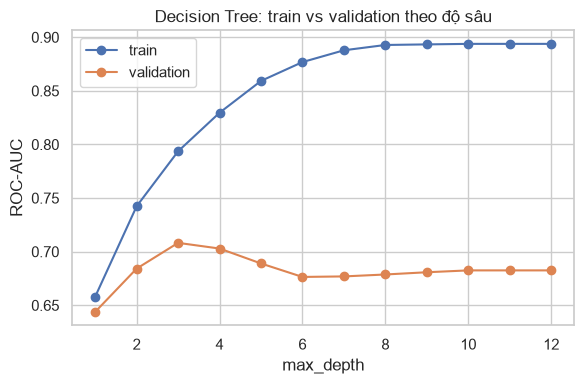

In [4]:
# Đường cong AUC theo max_depth: cho thấy cây sâu bị overfit
rows = []
for d in range(1, 13):
    p = dt_base.set_params(m__max_depth=d, m__min_samples_leaf=20)
    tr = cross_validate(p, X_train, y_train, cv=cv, scoring="roc_auc", return_train_score=True)
    rows.append({"max_depth": d, "train": tr["train_score"].mean(), "validation": tr["test_score"].mean()})
curve = pd.DataFrame(rows).set_index("max_depth")
curve.plot(marker="o", figsize=(6, 4)); plt.ylabel("ROC-AUC"); plt.title("Decision Tree: train vs validation theo độ sâu")
plt.tight_layout(); plt.show()

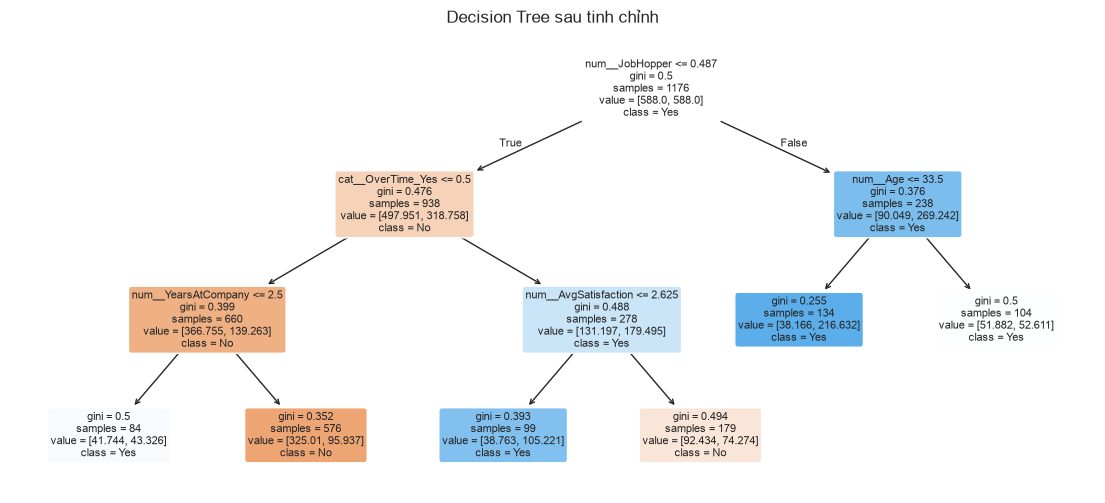

In [5]:
best_dt = dt_search.best_estimator_
names = best_dt.named_steps["pre"].get_feature_names_out()
plt.figure(figsize=(14, 6))
plot_tree(best_dt.named_steps["m"], feature_names=names, class_names=["No", "Yes"],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree sau tinh chỉnh"); plt.show()

## 3. XGBoost: tìm tham số rộng hơn, rồi tinh lại quanh vùng tốt nhất

In [6]:
xgb_base = Pipeline([("pre", make_preprocessor()),
                     ("m", XGBClassifier(scale_pos_weight=pos_weight, eval_metric="logloss",
                                         random_state=RS, n_jobs=-1))])

xgb_dist = {"m__n_estimators": [100, 200, 300, 500],
            "m__max_depth": [2, 3, 4, 5],
            "m__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "m__subsample": [0.6, 0.8, 1.0],
            "m__colsample_bytree": [0.5, 0.6, 0.8, 1.0],
            "m__min_child_weight": [1, 3, 5, 7],
            "m__gamma": [0, 0.5, 1, 2],
            "m__reg_alpha": [0, 0.1, 1],
            "m__reg_lambda": [1, 5, 10]}

xgb_rand = RandomizedSearchCV(xgb_base, xgb_dist, n_iter=40, scoring="roc_auc", cv=cv,
                              random_state=RS, n_jobs=-1).fit(X_train, y_train)
print(f"XGB random search: CV ROC-AUC = {xgb_rand.best_score_:.3f}\n{xgb_rand.best_params_}")

XGB random search: CV ROC-AUC = 0.827
{'m__subsample': 0.6, 'm__reg_lambda': 5, 'm__reg_alpha': 0.1, 'm__n_estimators': 200, 'm__min_child_weight': 1, 'm__max_depth': 3, 'm__learning_rate': 0.03, 'm__gamma': 1, 'm__colsample_bytree': 0.5}


In [7]:
# Tinh lại (GridSearch nhỏ) quanh bộ tham số tốt nhất của bước random
bp = xgb_rand.best_params_
def around(v, opts): 
    i = opts.index(v); return opts[max(i-1, 0): i+2]
fine_grid = {"m__max_depth": around(bp["m__max_depth"], xgb_dist["m__max_depth"]),
             "m__learning_rate": around(bp["m__learning_rate"], xgb_dist["m__learning_rate"]),
             "m__n_estimators": around(bp["m__n_estimators"], xgb_dist["m__n_estimators"]),
             "m__min_child_weight": around(bp["m__min_child_weight"], xgb_dist["m__min_child_weight"])}
fixed = {k: v for k, v in bp.items() if k not in fine_grid}
xgb_fine = GridSearchCV(xgb_rand.best_estimator_.set_params(**fixed), fine_grid,
                        scoring="roc_auc", cv=cv, n_jobs=-1).fit(X_train, y_train)
print(f"XGB fine grid: CV ROC-AUC = {xgb_fine.best_score_:.3f}\n{xgb_fine.best_params_}")

XGB fine grid: CV ROC-AUC = 0.835
{'m__learning_rate': 0.05, 'm__max_depth': 4, 'm__min_child_weight': 1, 'm__n_estimators': 300}


## 4. So sánh cuối cùng (test set chạm một lần)

In [8]:
final = {"Decision Tree (tuned)": dt_search, "XGBoost (random)": xgb_rand, "XGBoost (random + fine)": xgb_fine}
out = []
for name, s in final.items():
    p = s.best_estimator_.predict_proba(X_test)[:, 1]
    out.append({"model": name, "CV ROC-AUC": s.best_score_,
                "Test ROC-AUC": roc_auc_score(y_test, p), "Test PR-AUC": average_precision_score(y_test, p)})
result = pd.DataFrame(out).set_index("model").round(3)
result["Gap (CV - Test)"] = (result["CV ROC-AUC"] - result["Test ROC-AUC"]).round(3)
display(result)
result.to_csv("../data/model_comparison_02.csv")

,CV ROC-AUC,Test ROC-AUC,Test PR-AUC,Gap (CV - Test)
model,,,,
Decision Tree (tuned),0.732,0.639,0.228,0.093
XGBoost (random),0.827,0.794,0.495,0.033
XGBoost (random + fine),0.835,0.791,0.504,0.044


## 5. Nhận xét
- **Decision Tree:** cây không giới hạn độ sâu bị overfit rõ rệt: CV ROC-AUC chỉ đạt 0.584, và biểu đồ cho thấy AUC train tăng lên khoảng 0.89 trong khi AUC validation đạt đỉnh khoảng 0.71 ở `max_depth=3` rồi giảm về khoảng 0.68. Sau khi giới hạn `max_depth=3` và `min_samples_leaf=40`, CV ROC-AUC tăng lên 0.732, nhưng vẫn thấp hơn XGBoost khoảng 0.10 và chỉ đạt 0.639 trên tập test. Một cây đơn giản không đủ khả năng dự đoán nghỉ việc, chỉ phù hợp để minh họa và diễn giải.
- **XGBoost:** sau tuning đạt CV ROC-AUC 0.827 (random search) và 0.835 (thêm fine grid); Test ROC-AUC lần lượt 0.794 và 0.791, PR-AUC khoảng 0.50 (mức cơ sở 0.16). Fine grid chỉ tăng CV 0.008, trong khi Test không tăng và Gap tăng từ 0.033 lên 0.044, nên mức cải thiện này nằm trong phạm vi nhiễu, chưa đủ để kết luận bước tinh chỉnh thứ hai có ích.
- **So với Logistic Regression ở notebook 01 (CV ≈ 0.830):** XGBoost tuned chỉ cao hơn khoảng 0.005, nhỏ hơn nhiều so với độ lệch chuẩn CV (~0.02–0.03), nên không thể khẳng định XGBoost tốt hơn. Mô hình phức tạp không mang lại lợi thế rõ rệt trên bộ dữ liệu này.
- **Gap CV – Test:** Decision Tree có Gap lớn nhất (0.093), nghĩa là kém ổn định nhất khi gặp dữ liệu mới. Tập test chỉ có 47 mẫu dương nên AUC test dao động mạnh, các chênh lệch dưới ~0.02 giữa hai mô hình XGBoost không đáng tin để so sánh.
- **Kết luận cho nhóm:** nếu cần mô hình để dự đoán, XGBoost tuned (CV ≈ 0.83) và Logistic Regression cho kết quả tương đương, Decision Tree không nên dùng riêng lẻ để dự đoán. Decision Tree vẫn hữu ích để minh họa các quy tắc dễ đọc cho phòng HR.